# Company Revenue SVR

## Importing the libraries

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

## Loading the dataset

In [ ]:
df = pd.read_csv('Fortune 1000 Companies by Revenue.csv', na_values=['-']) # replace '-' with null

df.columns = df.columns.str.strip() # remove white spaces

## Data Exploration and Cleaning

### Primary Data Exploration

In [ ]:
def rule(t=''): print(f'\n{"─"*70}\n{t}') # Define 'rule', for exploration and cleaning prints



rule('1. shape and duplicates')

print(f'Shape: {df.shape}')

print(f'Duplicate rows: {df.duplicated().sum()}')



rule('2. Check Types')

print(df.dtypes)



rule('3. accounting negatives, losses written as ($4,539), not -4539,')

print(df[df['profits'].str.contains(r'[(\u2212-]', na=False)]['profits'].head())

print(df[df['profits'].str.contains(r'[(\u2212-]', na=False)]['revenue_percent_change'].head())

print(df[df['profits'].str.contains(r'[(\u2212-]', na=False)]['profits_percent_change'].head())



rule('4. nulls per column')

print(df.isna().sum())


──────────────────────────────────────────────────────────────────────
1. shape and duplicates
Shape: (1000, 10)
Duplicate rows: 0

──────────────────────────────────────────────────────────────────────
2. Check Types
rank                       object
name                       object
revenues                   object
revenue_percent_change     object
profits                    object
profits_percent_change     object
assets                     object
market_value               object
change_in_rank            float64
employees                  object
dtype: object

──────────────────────────────────────────────────────────────────────
3. accounting negatives, losses written as ($4,539), not -4539,
8      ($4,539)
47     ($6,520)
59     ($4,202)
113    ($1,993)
145    ($1,964)
Name: profits, dtype: object
8       3.10%
47     -6.80%
59      7.10%
113    72.40%
145    60.40%
Name: revenue_percent_change, dtype: object
8      -604.30%
47     -214.30%
59          NaN
113         NaN
145 

### Data Cleaning

#### To Number Helper Function

In [ ]:
def to_num(s):

    return (s.str.replace(r'[$,%]', '', regex=True)

             .str.replace(r'^\((.*)\)$', r'-\1', regex=True)

             .astype(float))

In [ ]:
columns = ['revenues','revenue_percent_change', 'profits','profits_percent_change',

           'assets', 'market_value', 'employees']

for col in columns:

    df[col] = to_num(df[col])



rule('Types After Clean')

print(df.dtypes)



rule('Negatives survived the sign conversion')

print((df[columns] < 0).sum())





──────────────────────────────────────────────────────────────────────
Types After Clean
rank                       object
name                       object
revenues                  float64
revenue_percent_change    float64
profits                   float64
profits_percent_change    float64
assets                    float64
market_value              float64
change_in_rank            float64
employees                 float64
dtype: object

──────────────────────────────────────────────────────────────────────
Negatives survived the sign conversion
revenues                    0
revenue_percent_change    120
profits                   114
profits_percent_change    142
assets                      0
market_value                0
employees                   0
dtype: int64


### Further Exploration

In [ ]:
rule("7. change_in_rank: does '-' mean 'no change' or 'new entrant'?")

print(df[df['change_in_rank'].isna()]['rank'].describe())



rule('8. profits_percent_change: is it undefined after a bad 2020?')

print(df[df['profits_percent_change'].isna()]['profits'].describe())



rule('8.1. ...it is. Back-compute 2020 profit where the % change exists')

p2020 = df['profits'] / (1 + df['profits_percent_change'] / 100)

print(f'{(p2020 <= 0).sum()} of {p2020.notna().sum()} implied 2020 profits are <= 0')



rule('9. revenue_percent_change nulls — new to the list?')

print(df[df['revenue_percent_change'].isna()][['name', 'rank']])



rule('10. market_value nulls — which companies?')

print(df[df['market_value'].isna()]['name'].head(20).tolist())



rule('11. distributions and skew')

print(df.describe().T)

print('\nskew:\n', df.skew(numeric_only=True))



rule('12. rows surviving a listwise drop')

print(f'{df.dropna().shape[0]} of {df.shape[0]}')



rule('13. impossible values — a company cannot have zero or negative revenue, assets or employees')

print((df[['revenues', 'assets', 'employees']] <= 0).sum())



rule('14. domain check — inspect both extremes with names attached')

print(df.nlargest(5, 'revenues')[['name', 'revenues', 'employees', 'assets']])

print()

print(df.nsmallest(5, 'revenues')[['name', 'revenues', 'employees', 'assets']])


──────────────────────────────────────────────────────────────────────
7. change_in_rank: does '-' mean 'no change' or 'new entrant'?
count     80
unique    80
top        1
freq       1
Name: rank, dtype: object

──────────────────────────────────────────────────────────────────────
8. profits_percent_change: is it undefined after a bad 2020?
count      270.000000
mean       776.557778
std       2846.492233
min      -4439.000000
25%       -103.650000
50%        156.050000
75%        581.675000
max      23040.000000
Name: profits, dtype: float64

──────────────────────────────────────────────────────────────────────
8.1. ...it is. Back-compute 2020 profit where the % change exists
0 of 727 implied 2020 profits are <= 0

──────────────────────────────────────────────────────────────────────
9. revenue_percent_change nulls — new to the list?
                  name rank
394  Jackson Financial  395
429      GXO Logistics  430
479  Victoria's Secret  480
556         Concentrix  557
619   On

### Exploration Summary






1.  Source and shape  

    * Fortune 1000 by revenue 2022. 1,000 rows × 10 columns, 0 duplicates. (check 1)  



2.  What arrived, and what had to be parsed  

    * Data was numeric, every column read as object, `$`, `,` and `%` formatting throughout. (check 2)



    * Two different negative conventions in one file: accounting parentheses for money ($4,539), leading hyphen for percents -6.80% (check 3). to_num handles both; verified 114 negative profits survived.

    * Headers had inconsistent trailing whitespace — some columns, not all

    * `-` mapped to NaN at read time

3. Target and what is to be dropped

    * Target: `revenues`

    * `rank` dropped — rank is revenue rank, so it's a deterministic function of the target. Kept in df for exploration, never copied into X

    * `name` dropped — identifier, would one-hot into 1,000 columns

    * `revenue_percent_change`,`profits_percent_change` and `change_in_rank` kept, levels leak, rates don't. A rate of change reveals no level.

4. Nulls — different meanings, different treatments

| column | n | what it means | evidence | decision |

| --- | --- | --- | --- | --- |

| `change_in_rank` | 80 | no change, not missing |spans the rank range; rank 1 can't be a new entrant (check 7) | set to 0  |

| `profits_percent_change`|273 | undefined — 2020 was a loss | 0 of 727 back-computed 2020 profits ≤ 0 (check 8.1) | new column `lost_money_2020` + fill 0 |  

| `market_value`| 45 | not applicable — no shares exist | all mutuals/co-ops: State Farm, USAA, Publix, Northwestern Mutual… (check 10) | `is_public` column + impute median |  

| `revenue_percent_change` | 8 | no prior year — 2021 spin-offs | Victoria's Secret, GXO, Jackson Financial, Kontoor (check 9)| impute median |  

| `profits` / `employees` | 3/1 | ordinary gaps | - | drop rows|  



    * `profits_percent_change` missingness carries information about a year not in the dataset. That's why it becomes a feature rather than a hole. Not dropped even though `lost_money_2020` exists as it provides extra information, company going from 100M to 150M is genuinely different from one going 100M to 95M, and the `lost_money_2020` being 0 for both examples doesn't capture that.

5. Transformation

    * revenues log-transformed — positive skew, 6.845410 (check 11)

    * Note: metrics and epsilon now live in log units, so they're not comparable to dollar-space figures

6. Quality

    * No impossible values — nothing ≤ 0 in revenues, assets, employees (check 13)

    * Both extremes domain-checked against known companies (check 14)

    * The target is truncated from below. Bottom five span 2,107–2,124M — a cutoff, not a tail. The model is only entitled to speak about companies above ~2.1bn




## Before-Split Cleaning

In [ ]:
df = df.dropna(subset=['profits', 'employees'])

df['lost_money_2020'] = df['profits_percent_change'].isna().astype(int)

df['is_public']       = df['market_value'].notna().astype(int)

df = df.fillna({'change_in_rank': 0, 'profits_percent_change': 0})

## Splitting the Dataset into the Training Set and Test Set

In [ ]:
from sklearn.model_selection import train_test_split



FEATURES = ['revenue_percent_change', 'profits', 'profits_percent_change',

            'assets', 'market_value', 'change_in_rank', 'employees',

            'lost_money_2020', 'is_public']

TARGET = 'revenues'



X = df[FEATURES].values

y = np.log(df[TARGET].values) # log tranform target



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 74)


In [ ]:
print(X_train)

print(f'Shape: {X_train.shape}')

[[1.5300e+01 2.5910e+02 5.3200e+01 ... 1.3525e+04 0.0000e+00 1.0000e+00]
 [1.4200e+01 6.1090e+02 3.8200e+01 ... 2.2052e+04 0.0000e+00 1.0000e+00]
 [2.8300e+01 3.2400e+02 3.1200e+01 ... 1.3006e+04 0.0000e+00 1.0000e+00]
 ...
 [1.7150e+02 4.6665e+03 1.3300e+02 ... 3.2380e+03 0.0000e+00 1.0000e+00]
 [1.0500e+01 2.4620e+02 2.4400e+01 ... 3.6230e+03 0.0000e+00 1.0000e+00]
 [3.5600e+01 1.1490e+02 0.0000e+00 ... 1.1700e+04 1.0000e+00 1.0000e+00]]
Shape: (796, 9)


In [ ]:
print(X_test)

print(f'Shape: {X_test.shape}')

[[ 5.0700e+01 -8.1300e+01  0.0000e+00 ...  1.3360e+03  1.0000e+00
   1.0000e+00]
 [ 2.1800e+01  3.9800e+02  0.0000e+00 ...  6.8860e+03  1.0000e+00
   1.0000e+00]
 [ 1.5000e+01  2.4230e+02  0.0000e+00 ...  6.6110e+03  1.0000e+00
   1.0000e+00]
 ...
 [ 2.6900e+01  7.7690e+03  3.8900e+01 ...  3.1000e+04  0.0000e+00
   1.0000e+00]
 [ 3.1000e+00  1.9950e+03  0.0000e+00 ...  1.7100e+05  1.0000e+00
   1.0000e+00]
 [-3.0000e-01  1.0043e+03  2.1300e+01 ...  2.8830e+03  0.0000e+00
   1.0000e+00]]
Shape: (200, 9)


In [ ]:
print(y_train)

print(f'Shape: {y_train.shape}')

[ 7.91366731  8.42112272  8.1565676   9.28340494  8.81827508  8.84127469
  9.73801131  9.18152929  8.29809146  7.92533826  8.79849998  9.98984872
  9.10178587 10.53128522  7.76476299 10.51192616  9.6668154   7.72250043
  9.44478779  7.66110346  9.42553239  8.89801035  8.30814976  7.78837738
  8.14937063  9.53777186  9.31560088  7.9776251  10.74473141 10.29170477
  8.08348292  8.90123035  9.74730147  9.9158113   8.42354164  8.07937017
  9.93508311  9.36357635  8.13373416 11.31942566  8.56174582  9.24113142
  9.60945201  8.46905282  9.30546872  8.05006542  7.95219293  7.75370938
  9.70710764 11.75197386  7.9279735  11.48542065  7.92472358  7.67628819
  9.05061753 10.2032958   7.97467048 10.44557926  8.61685751  8.43021818
  9.5062138   7.68909647  9.68787185  7.7147221   7.68045274 10.09017457
  9.5278482   9.23412526  8.51799287  8.10131404  9.1965558   8.12349854
  7.80954132 10.11362691  8.00590079  8.21324623  8.2763947   8.46282148
  8.43802011 10.07382087  9.42496776  7.98888225 12

In [ ]:
print(y_test)

print(f'Shape: {y_test.shape}')

[ 8.45746442  9.34136863  8.24687941  7.98019469  9.86594663  7.67689081
  8.50990671  9.27115321  8.22609195  7.77519184  8.85907932  7.90647356
  8.06192841  8.22841719 10.30558031 10.84346551  8.82423662  8.32651683
  8.61341205  9.34655691 11.05859044  8.1719385   9.80515782 11.28809299
  9.66713211  8.66440557  8.72230311  9.4582936   9.93906703  8.74327642
  9.4518031   9.20129963  9.42516139  8.00001409  8.47022736  8.56264445
  9.4006301   9.30891794  7.87203585  9.8877138   7.70773689  9.83874101
  7.74070788  9.08047084 10.23186281  8.25140307 11.17156128  8.21954159
  8.032555    9.87994765 11.27750688  8.93075874  9.14223282  8.29354952
 10.23221559  8.02335578 11.99821787  8.72842609  8.78543247  8.32288002
  9.86422684 10.78620082 12.52849667  7.65576936  8.11686487  8.1598323
  8.17157122  8.51246202  8.34671325  8.53054368  8.91757875  7.85476918
 11.16950515  8.20497249  8.73520359  9.06370637  9.2193794   8.54122217
  7.96852723  9.29434139  8.6516017   7.86045508  8.

## Linear Regression Baseline

In [ ]:
from sklearn.pipeline import make_pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.metrics import root_mean_squared_error

lin = make_pipeline(SimpleImputer(strategy='median'), LinearRegression())

lin.fit(X_train, y_train)

pred = lin.predict(X_test)

print(f'r2: {r2_score(y_test, pred):.3f}, rmse: {root_mean_squared_error(y_test, pred):.3f}')

r2: 0.331, rmse: 0.875


### Log-Scaled Features - Linear Regression Baseline

In [ ]:
LOG_COLS = ['assets', 'market_value', 'employees']

idx = [FEATURES.index(c) for c in LOG_COLS]



X_train_log, X_test_log = X_train.copy(), X_test.copy()

X_train_log[:, idx] = np.log(X_train_log[:, idx])

X_test_log[:, idx]  = np.log(X_test_log[:, idx])



lin_log = make_pipeline(SimpleImputer(strategy='median'), LinearRegression())

lin_log.fit(X_train_log, y_train)

pred = lin_log.predict(X_test_log)

print(f'log-X  r2: {r2_score(y_test, pred):.3f}, rmse: {root_mean_squared_error(y_test, pred):.3f}')

log-X  r2: 0.730, rmse: 0.556


##  Unscaled vs Scaled Features

In [ ]:
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR



unscaled_svr = make_pipeline(SimpleImputer(strategy='median'), SVR())

unscaled_svr.fit(X_train,y_train)



scaled_svr = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), SVR())

scaled_svr.fit(X_train,y_train)



unscaled_pred = unscaled_svr.predict(X_test)

scaled_pred = scaled_svr.predict(X_test)



print(f'unscaled svr: {len(unscaled_svr.named_steps['svr'].support_)}')

print(f'scaled svr: {len(scaled_svr.named_steps['svr'].support_)}')



print(f'unscaled  r2: {r2_score(y_test, unscaled_pred):.3f}, rmse: {root_mean_squared_error(y_test, unscaled_pred):.3f}')

print(f'scaled    r2: {r2_score(y_test, scaled_pred):.3f}, rmse: {root_mean_squared_error(y_test, scaled_pred):.3f}')

unscaled svr: 691
scaled svr: 682
unscaled  r2: 0.635, rmse: 0.646
scaled    r2: 0.673, rmse: 0.612


### Summary

| model | R² | RMSE (log units) | support vectors |

| --- | --- | --- | --- |

| `LinearRegression`, raw X | 0.331 | 0.875 | — |

| `LinearRegression`, log X | **0.730** | **0.556** | — |

| `SVR(rbf)`, unscaled X | 0.635 | 0.646 | 691 / 796 |

| `SVR(rbf)`, scaled X | 0.673 | 0.612 | 682 / 796 |



*All fits share `SimpleImputer(strategy='median')`. `y` is `log(revenues)`, unscaled in both SVR

arms. Defaults elsewhere: `C=1.0`, `epsilon=0.1`, `gamma='scale'`.*



> Scaling barely improved the model, R² moved 0.038, support vectors moved 9. On scaled X every column has variance 1, so every column contributes comparably Its the difference between a kernel that sees two or three columns versus a kernel that sees all nine. And all nine together bought 0.038 of R².




## Trying Different Epsilon Values

In [ ]:
for e in np.logspace(-3,1,5):



  pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), SVR(epsilon=e))

  pipe.fit(X_train,y_train)



  pred = pipe.predict(X_test)



  rule('e: ' + str(e))

  print(f'r2: {r2_score(y_test, pred):.3f}, rmse: {root_mean_squared_error(y_test, pred):.3f}')

  print(f'support vectors: {len(pipe.named_steps["svr"].support_)}')


──────────────────────────────────────────────────────────────────────
e: 0.001
r2: 0.666, rmse: 0.619
support vectors: 796

──────────────────────────────────────────────────────────────────────
e: 0.01
r2: 0.667, rmse: 0.618
support vectors: 789

──────────────────────────────────────────────────────────────────────
e: 0.1
r2: 0.673, rmse: 0.612
support vectors: 682

──────────────────────────────────────────────────────────────────────
e: 1.0
r2: 0.548, rmse: 0.720
support vectors: 99

──────────────────────────────────────────────────────────────────────
e: 10.0
r2: -1.757, rmse: 1.777
support vectors: 0


In [ ]:
for e in np.logspace(-1,0,5):



  pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), SVR(epsilon=e))

  pipe.fit(X_train,y_train)



  pred = pipe.predict(X_test)



  rule('e: ' + str(e))

  print(f'r2: {r2_score(y_test, pred):.3f}, rmse: {root_mean_squared_error(y_test, pred):.3f}')

  print(f'support vectors: {len(pipe.named_steps["svr"].support_)}')


──────────────────────────────────────────────────────────────────────
e: 0.1
r2: 0.673, rmse: 0.612
support vectors: 682

──────────────────────────────────────────────────────────────────────
e: 0.1778279410038923
r2: 0.667, rmse: 0.617
support vectors: 581

──────────────────────────────────────────────────────────────────────
e: 0.31622776601683794
r2: 0.659, rmse: 0.625
support vectors: 435

──────────────────────────────────────────────────────────────────────
e: 0.5623413251903491
r2: 0.641, rmse: 0.641
support vectors: 264

──────────────────────────────────────────────────────────────────────
e: 1.0
r2: 0.548, rmse: 0.720
support vectors: 99


### Summary

Epsilon sets how much error the model agrees to ignore. Inside the tube a point contributes nothing and never becomes a support vector; outside it, the point gets a say. At epsilon = 0.001 all 796 training points qualify and the model is free to listen to outliers; at epsilon = 10 the tube is wider than the entire spread of the target, no point qualifies, the sum in the prediction formula is empty, and the model collapses to a bare intercept — R² = −1.757.



**The support vector count is not a diagnosis of fit, it is a direct consequence of a number I chose.** I moved it from 796 to 0 without touching the data, the kernel, or `C`.



The two failures aren't symmetric. Epsilon = 10 costs R² −1.757; epsilon = 0.001 costs 0.007 against the peak. If a narrow tube were plainly overfitting those would be comparable. They aren't, because `C = 1.0` still caps how hard any single qualifying point can pull — epsilon decides *which* points get a say, `C` decides *how much*.



*All fits: `SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=<swept>)` on scaled X,

with `SimpleImputer(strategy='median')`. `y` is `log(revenues)`, unscaled.

`C=1.0` and `gamma='scale'` are sklearn's defaults and were held fixed —

`gamma='scale'` computes as 1/(n_features × X.var()), so the entire curve is conditional on those two values.*

## Plot

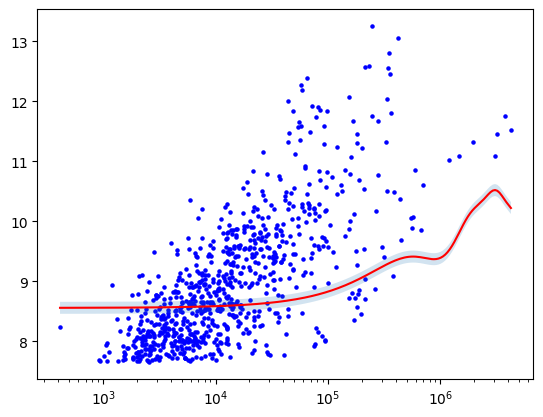

In [ ]:
pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), SVR(epsilon=0.1))

pipe.fit(X_train,y_train)



med = np.nanmedian(X_train, axis=0)

grid = np.tile(med, (200, 1))

xs = np.logspace(np.log10(X_train[:,3].min()), np.log10(X_train[:,3].max()), 200)



grid[:,3] = xs



pred = pipe.predict(grid)

fig, ax = plt.subplots()



ax.scatter(X_train[:,3], y_train, s = 5, c = 'blue')

ax.set_xscale('log')

ax.plot(xs, pred, c = 'red')

ax.fill_between(xs, pred - 0.1, pred + 0.1, alpha=0.2)

## Step 6 — `C`, `gamma`, and the scaler

> ⚠️ Cells from here to the end were written and run by Claude on 2026-09-28, at my instruction.
> Steps 1–5 above are mine.

In [ ]:
CS     = [0.1, 1, 10, 100]
GAMMAS = [0.001, 0.01, 0.1, 1.0]

def cv_grid(scaler, label, CS=CS, GAMMAS=GAMMAS):
    M = np.zeros((len(CS), len(GAMMAS)))
    for a, C in enumerate(CS):
        for b, g in enumerate(GAMMAS):
            pipe = make_pipeline(SimpleImputer(strategy='median'), scaler(),
                                 SVR(C=C, gamma=g, epsilon=0.1))
            M[a, b] = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()
    rule(label)
    print('          ' + ''.join(f'g={g:<9g}' for g in GAMMAS))
    for a, C in enumerate(CS):
        print(f'C={C:<8g}' + ''.join(f'{v:<11.4f}' for v in M[a]))
    ia, ib = np.unravel_index(M.argmax(), M.shape)
    print(f'best: C={CS[ia]}, gamma={GAMMAS[ib]}, cv r2={M[ia,ib]:.4f}')
    for tol in (0.01, 0.05):
        print(f'  cells within {tol} of best: {(M >= M.max()-tol).sum()} / {M.size}')
    ref = cross_val_score(make_pipeline(SimpleImputer(strategy='median'), scaler(), SVR()),
                          X_train, y_train, cv=5, scoring='r2').mean()
    print(f"  default (C=1, gamma='scale'): cv r2={ref:.4f}")
    best = make_pipeline(SimpleImputer(strategy='median'), scaler(),
                         SVR(C=CS[ia], gamma=GAMMAS[ib], epsilon=0.1)).fit(X_train, y_train)
    print(f'  TEST at best pair: r2={r2_score(y_test, best.predict(X_test)):.4f}'
          f'  SV={len(best[-1].support_)}')
    return M, (CS[ia], GAMMAS[ib])

M_std, best_std = cv_grid(StandardScaler, 'StandardScaler')
M_mm,  best_mm  = cv_grid(MinMaxScaler,   'MinMaxScaler')


──────────────────────────────────────────────────────────────────────
StandardScaler
          g=0.001    g=0.01     g=0.1      g=1        
C=0.1     0.0300     0.2779     0.4549     0.4053     
C=1       0.3463     0.5330     0.5999     0.6259     
C=10      0.4579     0.6003     0.6855     0.6592     
C=100     0.4505     0.5951     0.6759     0.5447     
best: C=10, gamma=0.1, cv r2=0.6855
  cells within 0.01 of best: 2 / 16
  cells within 0.05 of best: 3 / 16
  default (C=1, gamma='scale'): cv r2=0.6023
  TEST at best pair: r2=0.7025  SV=652

──────────────────────────────────────────────────────────────────────
MinMaxScaler
          g=0.001    g=0.01     g=0.1      g=1        
C=0.1     -0.0591    -0.0498    -0.0082    0.1222     
C=1       -0.0497    -0.0051    0.2233     0.4390     
C=10      -0.0048    0.2315     0.3744     0.5544     
C=100     0.2321     0.2550     0.2489     0.4973     
best: C=10, gamma=1.0, cv r2=0.5544
  cells within 0.01 of best: 1 / 16
  cells within

`MinMaxScaler`'s best cell sits on the `gamma` edge of the grid, so the grid is lying about
where its optimum is. Extend until the peak is interior.

In [ ]:
M_mm2, best_mm2 = cv_grid(MinMaxScaler, 'MinMaxScaler — extended gamma',
                          CS=[3, 10, 30], GAMMAS=[30, 100, 300, 1000])


──────────────────────────────────────────────────────────────────────
MinMaxScaler — extended gamma
          g=30       g=100      g=300      g=1000     
C=3       0.6305     0.6708     0.6600     0.5918     
C=10      0.6712     0.6773     0.6522     0.5760     
C=30      0.6646     0.6558     0.6189     0.5556     
best: C=10, gamma=100, cv r2=0.6773
  cells within 0.01 of best: 3 / 12
  cells within 0.05 of best: 8 / 12
  default (C=1, gamma='scale'): cv r2=0.4232
  TEST at best pair: r2=0.7321  SV=620


### Why the optimum moved: what `gamma='scale'` sees vs what the kernel feels

In [ ]:
from sklearn.metrics import pairwise_distances

imp = SimpleImputer(strategy='median').fit(X_train)
Xi  = imp.transform(X_train)
rng = np.random.default_rng(0)
sub = Xi[rng.choice(len(Xi), 300, replace=False)]

rule('pooled variance (what gamma=scale uses) vs median pairwise distance (what the kernel feels)')
for sc, lab in ((StandardScaler, 'StandardScaler'), (MinMaxScaler, 'MinMaxScaler')):
    full = sc().fit(Xi)
    var  = full.transform(Xi).var()
    D    = pairwise_distances(full.transform(sub)) ** 2
    med  = np.median(D[np.triu_indices_from(D, 1)])
    print(f'{lab:16s} pooled var={var:.6f}  gamma_scale={1/(Xi.shape[1]*var):.6f}'
          f'   median sq. dist={med:.6f}')


──────────────────────────────────────────────────────────────────────
pooled variance (what gamma=scale uses) vs median pairwise distance (what the kernel feels)
StandardScaler   pooled var=1.000000  gamma_scale=0.111111   median sq. dist=5.711517
MinMaxScaler     pooled var=0.143417  gamma_scale=0.774739   median sq. dist=0.051034


## Step 7 — Break it

In [ ]:
BEST = dict(C=10, gamma=0.1, epsilon=0.1)
def svr(**kw):
    p = dict(BEST); p.update(kw)
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), SVR(**p))
def lin():
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearRegression())

rule('7A. one corrupted training target  (y_train genuinely spans '
     f'{y_train.min():.2f} to {y_train.max():.2f})')
for mag in [0, 20, 50, 100, 1000]:
    yc = y_train.copy()
    if mag: yc[0] = mag
    s, l = svr().fit(X_train, yc), lin().fit(X_train, yc)
    ps, pl = s.predict(X_test), l.predict(X_test)
    tag = 'clean' if mag == 0 else f'y[0]={mag}'
    print(f'{tag:12s}  SVR r2={r2_score(y_test,ps):7.3f}   '
          f'LinReg r2={r2_score(y_test,pl):9.3f}')

print()
yc = y_train.copy(); yc[0] = 100
for name, mk in (('SVR', svr), ('LinReg', lin)):
    a = mk().fit(X_train, y_train); b = mk().fit(X_train, yc)
    sh = np.abs(a.predict(X_test) - b.predict(X_test))
    print(f'  {name:7s} mean |prediction shift| = {sh.mean():.5f}   max = {sh.max():.5f}')


──────────────────────────────────────────────────────────────────────
7A. one corrupted training target  (y_train genuinely spans 7.65 to 13.26)
clean         SVR r2=  0.702   LinReg r2=    0.331
y[0]=20       SVR r2=  0.702   LinReg r2=    0.329
y[0]=50       SVR r2=  0.702   LinReg r2=    0.321
y[0]=100      SVR r2=  0.702   LinReg r2=    0.299
y[0]=1000     SVR r2=  0.702   LinReg r2=   -1.859

  SVR     mean |prediction shift| = 0.00250   max = 0.01759
  LinReg  mean |prediction shift| = 0.12174   max = 0.33013


Why is SVR completely unmoved? The dual coefficients are box-constrained to $[-C, C]$.
Look at the corrupted point's weight directly.

In [ ]:
yc = y_train.copy(); yc[0] = 1000
m = svr().fit(X_train, yc)
s = m[-1]
rule('7A(ii). the cap, made visible')
print('row 0 is a support vector :', 0 in s.support_)
pos = list(s.support_).index(0)
print(f'its dual coef             : {s.dual_coef_[0][pos]:.6f}   (C = 10)')
print(f'max |dual coef| anywhere  : {np.abs(s.dual_coef_[0]).max():.6f}')
print(f'how many sit at the cap   : {(np.abs(s.dual_coef_[0]) >= 10-1e-9).sum()}'
      f' of {s.dual_coef_.shape[1]}')


──────────────────────────────────────────────────────────────────────
7A(ii). the cap, made visible
row 0 is a support vector : True
its dual coef             : 10.000000   (C = 10)
max |dual coef| anywhere  : 10.000000
how many sit at the cap   : 561 of 650


In [ ]:
rule('7B. gamma pushed high — the median-held slice, and the train/test gap')
i   = FEATURES.index('assets')
med = np.nanmedian(X_train, axis=0)
grid = np.tile(med, (400, 1))
xs   = np.logspace(np.log10(X_train[:, i].min()), np.log10(X_train[:, i].max()), 400)
grid[:, i] = xs

print(f'{"gamma":>8}  {"train r2":>9} {"test r2":>9} {"gap":>7}   slice span')
for g in [0.1, 1, 10, 100, 1000]:
    m = svr(gamma=g).fit(X_train, y_train)
    tr = r2_score(y_train, m.predict(X_train))
    te = r2_score(y_test,  m.predict(X_test))
    curve = m.predict(grid)
    print(f'{g:>8g}  {tr:>9.4f} {te:>9.4f} {tr-te:>7.3f}   {curve.max()-curve.min():.4f}')
print(f'  (y_train spans {y_train.max()-y_train.min():.3f} log units)')


──────────────────────────────────────────────────────────────────────
7B. gamma pushed high — the median-held slice, and the train/test gap
   gamma   train r2   test r2     gap   slice span
     0.1     0.7957    0.7025   0.093   1.9752
       1     0.9062    0.6711   0.235   1.5811
      10     0.9710    0.5557   0.415   1.9349
     100     0.9916    0.2529   0.739   0.9660
    1000     0.9915    0.0283   0.963   0.0589
  (y_train spans 5.605 log units)


In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

for g in [0.1, 10, 1000]:
    m = svr(gamma=g).fit(X_train, y_train)
    a1.plot(xs, m.predict(grid), label=f'gamma={g:g}')
a1.scatter(X_train[:, i], y_train, s=4, alpha=.25, c='0.6', zorder=0)
a1.set_xscale('log'); a1.set_xlabel('assets'); a1.set_ylabel('log(revenues)')
a1.set_title('the slice: high gamma looks FLAT'); a1.legend()

gs = [0.1, 1, 10, 100, 1000]
tr = [r2_score(y_train, svr(gamma=g).fit(X_train, y_train).predict(X_train)) for g in gs]
te = [r2_score(y_test,  svr(gamma=g).fit(X_train, y_train).predict(X_test))  for g in gs]
a2.semilogx(gs, tr, 'o-', label='train'); a2.semilogx(gs, te, 'o-', label='test')
a2.set_xlabel('gamma'); a2.set_ylabel('R²')
a2.set_title('the truth: high gamma OVERFITS'); a2.legend(); a2.axhline(0, lw=.5, c='k')
plt.tight_layout()

In [ ]:
rule('7C. was RBF the right call?')
for k in ['rbf', 'linear', 'poly', 'sigmoid']:
    kw = dict(kernel=k)
    if k == 'poly': kw['degree'] = 3
    m = svr(**kw).fit(X_train, y_train)
    p = m.predict(X_test)
    print(f'{k:9s} r2={r2_score(y_test,p):12.3f} '
          f'rmse={root_mean_squared_error(y_test,p):8.3f} SV={len(m[-1].support_)}')
print()
print('  poly by degree:', {d: round(r2_score(y_test,
      svr(kernel='poly', degree=d).fit(X_train, y_train).predict(X_test)), 3)
      for d in [2, 3, 4]})
print('  log-X LinearRegression baseline, for comparison: 0.730')


──────────────────────────────────────────────────────────────────────
7C. was RBF the right call?
rbf       r2=       0.702 rmse=   0.584 SV=652
linear    r2=       0.219 rmse=   0.946 SV=709
poly      r2=      -0.207 rmse=   1.176 SV=731
sigmoid   r2=   -6492.681 rmse=  86.233 SV=793

  poly by degree: {2: -1.871, 3: -0.207, 4: -11.911}
  log-X LinearRegression baseline, for comparison: 0.730


### Summary — see `findings.md` §4–§9

| model | test R² |
| --- | ---: |
| `LinearRegression`, raw X | 0.331 |
| `SVR(rbf)`, defaults | 0.673 |
| **`LinearRegression`, log X (hand-engineered)** | **0.730** |
| `SVR(rbf)` tuned, `StandardScaler` (C=10, γ=0.1) | 0.703 |
| `SVR(rbf)` tuned, `MinMaxScaler` (C=10, γ=100) | 0.732 |

Three results worth carrying out of this:

1. **The scaler moved optimal `gamma` by 1,000×; `gamma='scale'` moved by 7×.** Trusting the
   default under `MinMaxScaler` costs 0.25 of CV R², silently.
2. **SVR ignored a corrupted target entirely** — R² identical to three decimals with one
   company's log-revenue set to 1000 — because `dual_coef_` is capped at `C`. The cap is
   directly readable: exactly `10.000000`.
3. **High `gamma` overfits, but the step-5 slice renders it as a flat line.** Train R² 0.992,
   test 0.028, and a curve span of 0.06 log units. A partial-dependence slice runs through a
   region with no data; check the train/test gap, not the picture.